
# Pontificia Universidad Javeriana

**Fecha**: 2 de octubre 2024

**Profesor**: John Corredor, PhD

**Materia**: Procesamiento de Alto Volumen de Datos

**Objetivo**: Segundo Parcial **Modelo A**

**Sara Juliana Peña Gómez**:

**ID Estudiante**:

**Contexto**
- Se presenta un conjunto de datos (dataset) los cuales representan las ventas de productos en el año 2019
- Cada dataset tiene los siguientes campos
     
      - ID Orden: identificador de orden de compra
     
      - Producto: Descripción de producto
     
      - Cantidad Ordenada: cantidad de productos del mismo tipo ordenados/pedidos/comprados
     
      - Precio Unitarios: valor comercial del producto
     
      - Fecha: fecha del producto vendido, formato: mes/día/año hora
     
      - Dirección de compra: dirección de venta del producto, formato: dirección, ciudad, iniciales del departamento

- El conjunto de datos se ubica en la carpeta del [enlace](<https://github.com/corredor-john/ExploratoryDataAnalisys/tree/main/Ventas>)
- A continuación de se presenta los pasos a seguir a para el desarrollo del parcial

### 1. Cargar las bibliotecas necesarias y la sesión PYSPARK**

Se installa pyspark y demás librerias necesarias para el desarrollo

In [0]:
pip install pyspark

Python interpreter will be restarted.
Python interpreter will be restarted.


In [0]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import random

from pyspark import SparkFiles
from pyspark.sql import SparkSession
from pyspark.ml import Pipeline
from pyspark.sql import SQLContext
from pyspark.sql.session import SparkSession
from pyspark.sql.types import IntegerType, FloatType, DoubleType, StringType
from pyspark.sql.functions import mean, col, split, when, isnan, count, udf, lit, to_date, month, substring, regexp_replace, unix_timestamp, concat_ws, isnull
from pyspark.sql import functions as F
from pyspark.ml.feature import StringIndexer, VectorAssembler

Se leventa la sesión con PySpark

In [0]:
spark = SparkSession.builder.appName("Parcial_SaraP").getOrCreate()

### 2. DataFrame PySpark (10 pts)
**2.1.- Crear un dataframe PySpark con los conjuntos de datos de la carpeta dada en el enlace**

In [0]:
# Se carga el conjunto de datos
url = "https://raw.githubusercontent.com/corredor-john/ExploratoryDataAnalisys/refs/heads/main/Ventas/Ventas_June_2019.csv"
spark.sparkContext.addFile(url)

In [0]:
# Se visualiza el conjunto de datos para ver cuales son sus variables
# Se crea la variable donde se va a almacenar el Dataframe. 
path = SparkFiles.get("Ventas_June_2019.csv")
dfVentas = spark.read.csv("file://"+path, inferSchema = True, header = True, sep = ",")
dfVentas.show()

+--------+--------------------+------------------+----------------+--------------+--------------------+
|ID Orden|           Producto | Cantidad Ordenada|Precio Unitario |         Fecha| Dirección de Compra|
+--------+--------------------+------------------+----------------+--------------+--------------------+
|  195098|Cable de Carga Li...|                 1|           64900|06/17/19 20:12|736 calle Transve...|
|  195099|Cable de Carga Li...|                 1|           64900|06/25/19 00:27|562 calle Elm, Me...|
|  195100|Freidora Air Frye...|                 1|          198849|06/23/19 20:44|548 calle Sucre, ...|
|  195101|AAA Batteries (4-...|                 1|           12990|06/12/19 20:30|322 calle Sur, Me...|
|  195102|AA Batteries (4-p...|                 1|           13800|06/02/19 10:00|928 calle Avenida...|
|  195103| Xiaomi REDMI Note 8|                 1|          719000|06/03/19 00:01|482 calle Cedar, ...|
|  195104|Cable de Carga US...|                 2|           469

####2.2.- Presentar el tipo de datos del dataframe spark (5 pts)

In [0]:
dfVentas.printSchema()

root
 |-- ID Orden: integer (nullable = true)
 |-- Producto : string (nullable = true)
 |--  Cantidad Ordenada: integer (nullable = true)
 |-- Precio Unitario : integer (nullable = true)
 |-- Fecha: string (nullable = true)
 |-- Dirección de Compra: string (nullable = true)



####2.3.-Se requiere cambiar los nombres de las columnas: (3 pts)
  - 'Producto '->'Producto'
  - ' Cantidad Ordenada'->'Cantidad'
  - 'Precio Unitario '->'Precio_Unitario'

In [0]:
#Se cambian los nombres de las columnas y se hace un control de versión
#Se decidio que es mejor dejar "ID Orden" como "ID" para evitar futuros errores
#Se realizo un control de versiones

nuevasColumnas = ['ID', 'Producto', 'Cantidad', 'Precio_Unitario']
dfVentas1 = dfVentas

for antes, despues in zip (dfVentas.columns, nuevasColumnas):
    dfVentas1 = dfVentas1.withColumnRenamed(antes, despues)

dfVentas1.columns

Out[6]: ['ID',
 'Producto',
 'Cantidad',
 'Precio_Unitario',
 'Fecha',
 'Dirección de Compra']

####2.4.- Convertir las columnas requeridas a los tipos de datos correspondientes (2 pts)

In [0]:
#ID, Producto, Cantidad, y Direccion_Compra estan en formato correcto. Sin embargo, la variable Fecha se encuentra en String y se pasará a tipo date y Precio_Unitario se cambia a Double en caso de que haya algun valor con decimal. 
dfVentas1 = dfVentas1.withColumn("Precio_Unitario", dfVentas1.Precio_Unitario.cast(DoubleType()))
dfVentas1.select("Fecha").show(truncate=False)

# Se utilizara la función "unix_timestamp" para permitir el casteo a tipo fecha y que no afecte la hora
dfVentas1 = dfVentas1.withColumn("Fecha", unix_timestamp(col("Fecha"), "MM/dd/yy HH:mm").cast("timestamp"))

#Se visualiza como quedaron los cambios en el conjunto de datos
dfVentas1.show()

+--------------+
|Fecha         |
+--------------+
|06/17/19 20:12|
|06/25/19 00:27|
|06/23/19 20:44|
|06/12/19 20:30|
|06/02/19 10:00|
|06/03/19 00:01|
|06/03/19 22:59|
|06/23/19 15:29|
|06/26/19 10:27|
|06/06/19 12:47|
|06/02/19 13:56|
|06/05/19 17:11|
|06/20/19 10:35|
|06/09/19 15:46|
|06/24/19 18:32|
|06/05/19 16:25|
|06/22/19 15:52|
|06/30/19 18:37|
|06/07/19 19:03|
|06/12/19 18:40|
+--------------+
only showing top 20 rows

+------+--------------------+--------+---------------+-------------------+--------------------+
|    ID|            Producto|Cantidad|Precio_Unitario|              Fecha| Dirección de Compra|
+------+--------------------+--------+---------------+-------------------+--------------------+
|195098|Cable de Carga Li...|       1|        64900.0|2019-06-17 20:12:00|736 calle Transve...|
|195099|Cable de Carga Li...|       1|        64900.0|2019-06-25 00:27:00|562 calle Elm, Me...|
|195100|Freidora Air Frye...|       1|       198849.0|2019-06-23 20:44:00|548 calle Su

##3.- Creación de variables: derivación de variables *(20pts)*

####3.1.-Se requiere Crear nueva columna **Mes** a partir de la columna *Fecha* (5 pts)

In [0]:
#Se obtiene el mes de la columna Fecha con la función "month"
dfVentas1 = dfVentas1.withColumn("Mes", month(col("Fecha")))

#Se visualizan los cambios
dfVentas1.printSchema()
dfVentas1.show()

root
 |-- ID: integer (nullable = true)
 |-- Producto: string (nullable = true)
 |-- Cantidad: integer (nullable = true)
 |-- Precio_Unitario: double (nullable = true)
 |-- Fecha: timestamp (nullable = true)
 |-- Dirección de Compra: string (nullable = true)
 |-- Mes: integer (nullable = true)

+------+--------------------+--------+---------------+-------------------+--------------------+---+
|    ID|            Producto|Cantidad|Precio_Unitario|              Fecha| Dirección de Compra|Mes|
+------+--------------------+--------+---------------+-------------------+--------------------+---+
|195098|Cable de Carga Li...|       1|        64900.0|2019-06-17 20:12:00|736 calle Transve...|  6|
|195099|Cable de Carga Li...|       1|        64900.0|2019-06-25 00:27:00|562 calle Elm, Me...|  6|
|195100|Freidora Air Frye...|       1|       198849.0|2019-06-23 20:44:00|548 calle Sucre, ...|  6|
|195101|AAA Batteries (4-...|       1|        12990.0|2019-06-12 20:30:00|322 calle Sur, Me...|  6|
|195

####3.2.-Se requiere Crear 3 nuevas columnas (**Dirección**, **Ciudad**, **Departamento**) a partir de la columna *Dirección de Compra* (5 pts)

In [0]:
#Se utilizo la función "split" para dividir la información en Dirección, Ciudad y Departamento. Cada uno se guardo en una nueva columna

dfVentas1 = dfVentas1.withColumn("Direccion", split(col("Dirección de Compra"), ",")[0]) \
       .withColumn("Ciudad", split(col("Dirección de Compra"), ",")[1]) \
       .withColumn("Departamento", split(col("Dirección de Compra"), ",")[2])

#Se visualiza el resultado
dfVentas1.show()

+------+--------------------+--------+---------------+-------------------+--------------------+---+--------------------+-------------+------------+
|    ID|            Producto|Cantidad|Precio_Unitario|              Fecha| Dirección de Compra|Mes|           Direccion|       Ciudad|Departamento|
+------+--------------------+--------+---------------+-------------------+--------------------+---+--------------------+-------------+------------+
|195098|Cable de Carga Li...|       1|        64900.0|2019-06-17 20:12:00|736 calle Transve...|  6|736 calle Transve...|     Medellin|          AN|
|195099|Cable de Carga Li...|       1|        64900.0|2019-06-25 00:27:00|562 calle Elm, Me...|  6|       562 calle Elm|     Medellin|          AN|
|195100|Freidora Air Frye...|       1|       198849.0|2019-06-23 20:44:00|548 calle Sucre, ...|  6|     548 calle Sucre|     Medellin|          AN|
|195101|AAA Batteries (4-...|       1|        12990.0|2019-06-12 20:30:00|322 calle Sur, Me...|  6|       322 ca

####3.3.-Se requiere crear una nueva columna 'Ciudad(Departamento)', a partir de las columnas Ciudad y Departamento (5 pts)

In [0]:
# Concatenar las columnas "Ciudad" y "Departamento" con el formato "Ciudad(Departamento)"
dfVentas1 = dfVentas1.withColumn("Ciudad(Departamento)", concat_ws("(", col("Ciudad"), col("Departamento")))

# Se agrega ')' para mostrar el formato correcto
dfVentas1 = dfVentas1.withColumn("Ciudad(Departamento)", concat_ws(")", col("Ciudad(Departamento)"), lit('')))

#Se visualizan los cambios
dfVentas1.show()

+------+--------------------+--------+---------------+-------------------+--------------------+---+--------------------+-------------+------------+--------------------+
|    ID|            Producto|Cantidad|Precio_Unitario|              Fecha| Dirección de Compra|Mes|           Direccion|       Ciudad|Departamento|Ciudad(Departamento)|
+------+--------------------+--------+---------------+-------------------+--------------------+---+--------------------+-------------+------------+--------------------+
|195098|Cable de Carga Li...|       1|        64900.0|2019-06-17 20:12:00|736 calle Transve...|  6|736 calle Transve...|     Medellin|          AN|       Medellin( AN)|
|195099|Cable de Carga Li...|       1|        64900.0|2019-06-25 00:27:00|562 calle Elm, Me...|  6|       562 calle Elm|     Medellin|          AN|       Medellin( AN)|
|195100|Freidora Air Frye...|       1|       198849.0|2019-06-23 20:44:00|548 calle Sucre, ...|  6|     548 calle Sucre|     Medellin|          AN|       M

####3.4.- Eliminar las columnas: 'Dirección de Compra', 'Ciudad', 'Departamento' (5 pts)

In [0]:
#Se utiliza la función "drop" para quitar 'Dirección de Compra', 'Ciudad', 'Departamento' del Conjunto de Datos
#Se hace control de versiones
dfVentas2 = dfVentas1

dfVentas2 = dfVentas2.drop('Dirección de Compra', 'Ciudad', 'Departamento')
#Se visualizan los cambios
dfVentas2.show(100)

+------+--------------------+--------+---------------+-------------------+---+--------------------+--------------------+
|    ID|            Producto|Cantidad|Precio_Unitario|              Fecha|Mes|           Direccion|Ciudad(Departamento)|
+------+--------------------+--------+---------------+-------------------+---+--------------------+--------------------+
|195098|Cable de Carga Li...|       1|        64900.0|2019-06-17 20:12:00|  6|736 calle Transve...|       Medellin( AN)|
|195099|Cable de Carga Li...|       1|        64900.0|2019-06-25 00:27:00|  6|       562 calle Elm|       Medellin( AN)|
|195100|Freidora Air Frye...|       1|       198849.0|2019-06-23 20:44:00|  6|     548 calle Sucre|       Medellin( AN)|
|195101|AAA Batteries (4-...|       1|        12990.0|2019-06-12 20:30:00|  6|       322 calle Sur|       Medellin( AN)|
|195102|AA Batteries (4-p...|       1|        13800.0|2019-06-02 10:00:00|  6|   928 calle Avenida|         Ibagué( TO)|
|195103| Xiaomi REDMI Note 8|   

##4.- Limpieza de Datos y Análisis Exploratorio de Datos (40 pts)

####4.1.- Se requiere una tabla que presente la cantidad de datos nulos por variable (1pts)

In [0]:
#Al cambiar el tipo de dato en Fecha, se necesita plantear el siguiente metodo para evaluar el resultado. Producto no tiene null porque más adelante se quitaron los null
#La función check_null_or_nan identifica valores faltantes (nulos o NaN) en columnas numéricas. Luego, el se itera sobre cada columna del DataFrame dfVentas2 y utiliza esta función para contar los valores faltantes, creando un nuevo DataFrame con el conteo para cada columna

def check_null_or_nan(column):
    if isinstance(column.dataType, (DoubleType, FloatType)):
        return isnan(column) | isnull(column)
    elif isinstance(column.dataType, IntegerType):
        return isnull(column)
    else:
        return isnull(column)

result = dfVentas2.select([
    count(when(check_null_or_nan(col(c)), c)).alias(c)
    for c in dfVentas2.columns
])

#Se muestra el resultado
result.show()

+---+--------+--------+---------------+-----+---+---------+--------------------+
| ID|Producto|Cantidad|Precio_Unitario|Fecha|Mes|Direccion|Ciudad(Departamento)|
+---+--------+--------+---------------+-----+---+---------+--------------------+
| 83|      51|      83|             83|   83| 83|       51|                   0|
+---+--------+--------+---------------+-----+---+---------+--------------------+



####4.2.- Se requiere que los valores nulos encontrados de la variable Producto, sean cambiados por el producto más vendido (8 pts)

In [0]:
#Se realizara con los siguientes pasos:
#1. Se encuentra el producto más vendido del DataFrame
producto_mas_vendido = dfVentas2.groupBy("Producto").count().orderBy(F.desc("count")).first()
#2. Se obtiene el nombre o "Producto" más vendido del DataFrame
producto_mas_vendido_nombre = producto_mas_vendido["Producto"]
#3. Se reemplaza los valores null de "Producto" por el más vendido
dfVentas2 = dfVentas2.withColumn(
    "Producto",
    F.when(F.col("Producto").isNull(), producto_mas_vendido_nombre)
    .otherwise(F.col("Producto"))
)
#4. Se verifica que la columna "Producto" ya no tenga datos null
result = dfVentas2.select(F.sum(F.when(check_null_or_nan(F.col("Producto")), 1).otherwise(0)).alias("null_count"))
#Se muestra
result.show()

+----------+
|null_count|
+----------+
|         0|
+----------+



####4.3.-Se requiere saber el promedio de precios de cada Producto (1 pts)

In [0]:
#Se agrupa la columna "Producto", se calcula su promedio y se almacena en una nueva columna "Promedio_Precio"
promedio_producto = dfVentas2.groupBy("Producto").agg(F.avg("Precio_Unitario").alias("Promedio_Precio"))

#Se muestra el resultado
promedio_producto.show(truncate=False)

+---------------------------------+-----------------+
|Producto                         |Promedio_Precio  |
+---------------------------------+-----------------+
|Samsung Galaxy A20S              |489900.0         |
|LG Secadora Carga Frontal        |1646900.0        |
|Freidora Air Fryer Kalley K-MAF25|198849.0         |
|Audifonos Apple Airpods          |499900.0         |
|Motorola G8 Plus Red             |729900.0         |
|Asus VivoBook X420FA-BV Laptop   |1950900.0        |
|Cable de Carga Lightning         |64900.0          |
|AAA Batteries (4-pack)           |12990.0          |
|Samsung Galaxy A302              |649900.0         |
|Xiaomi REDMI Note 8              |719000.0         |
|Freidora Saludable B&D 3.5 Litros|229900.0         |
|LG Lavadora 19Kg Inv WT19        |1646900.0        |
|AA Batteries (4-pack)            |13800.0          |
|Producto                         |null             |
|Horno Microondas 0.8P Samsung AGE|309900.0         |
|Audifonos Bose SoundSport  

####4.4.- Se requiere que se sustituya los valores Nulos de la variable 'Precio_Unitario', cuando la variable Producto sea:
          - Cable de Carga USB-C P/O
          - Cable de Carga Lightning
####por el precio promedio de los dos productos anteriores (8 pts).

In [0]:
#Se realiza el siguiente procedimiento
#1. Se calcula el promedio de los precios de los productos que se quieren modificar
promedio_precio = dfVentas2.filter(F.col("Producto").isin("Cable de Carga USB-C P/O", "Cable de Carga Lightning")) \
                    .agg(F.avg("Precio_Unitario").alias("Promedio_Precio")) \
                    .first()["Promedio_Precio"]

#2. Reemplazar los valores null de Promedio_Precio de los productos que se quieren modificar por el promedio que se calculo en el paso 1
dfVentas2 = dfVentas2.withColumn(
    "Precio_Unitario",
    F.when(
        (F.col("Producto").isin("Cable de Carga USB-C P/O", "Cable de Carga Lightning")) & 
        F.col("Precio_Unitario").isNull(),
        promedio_precio
    ).otherwise(F.col("Precio_Unitario"))
)
#3. Mostrar los resultados
dfVentas2.show(truncate=False)

+------+---------------------------------+--------+---------------+-------------------+---+-------------------------+--------------------+
|ID    |Producto                         |Cantidad|Precio_Unitario|Fecha              |Mes|Direccion                |Ciudad(Departamento)|
+------+---------------------------------+--------+---------------+-------------------+---+-------------------------+--------------------+
|195098|Cable de Carga Lightning         |1       |64900.0        |2019-06-17 20:12:00|6  |736 calle Transversal    | Medellin( AN)      |
|195099|Cable de Carga Lightning         |1       |64900.0        |2019-06-25 00:27:00|6  |562 calle Elm            | Medellin( AN)      |
|195100|Freidora Air Fryer Kalley K-MAF25|1       |198849.0       |2019-06-23 20:44:00|6  |548 calle Sucre          | Medellin( AN)      |
|195101|AAA Batteries (4-pack)           |1       |12990.0        |2019-06-12 20:30:00|6  |322 calle Sur            | Medellin( AN)      |
|195102|AA Batteries (4-pac

####4.5.- ¿Cúantos valores nulos quedaron de la variable Precio_Unitario? (1pts)

In [0]:
# Se cuentan los valores nulos de la columna "Precio_Unitario"
num_nulos = dfVentas2.filter(F.col("Precio_Unitario").isNull()).count()

# Mostrar el número de valores nulos
print(f"Número de valores nulos en Precio_Unitario: {num_nulos}")

Número de valores nulos en Precio_Unitario: 32


####4.6.- Elimine los valores nulos restantes del Dataframe (verifique) (2pts)

In [0]:
#Estos son los pasos para eliminar los valores nulos restantates del Dataframe:
#Se realiza un control de versiones
#1. los valores nulos en todo el DataFrame
dfVentas3 = dfVentas2.dropna()

#2. Verificar si hay valores nulos restantes
dfVentas3.select([F.count(F.when(F.isnull(c), c)).alias(c) for c in dfVentas3.columns]).show()

+---+--------+--------+---------------+-----+---+---------+--------------------+
| ID|Producto|Cantidad|Precio_Unitario|Fecha|Mes|Direccion|Ciudad(Departamento)|
+---+--------+--------+---------------+-----+---+---------+--------------------+
|  0|       0|       0|              0|    0|  0|        0|                   0|
+---+--------+--------+---------------+-----+---+---------+--------------------+



####4.7.- Haga una tabla y un gráfico histograma de cantidad de ventas por mes (8pts)

In [0]:
#Tabla
#1. Se agrupa el mes para obtener la cantidad de ventas por mes
dfVentas4 = dfVentas3
dfVentas4 = dfVentas4.groupBy("Mes").agg(F.sum("Cantidad").alias("Ventas"))

# Mostrar la tabla con la cantidad de ventas por mes
dfVentas4.show(truncate=False)


+---+------+
|Mes|Ventas|
+---+------+
|6  |18318 |
|7  |22    |
+---+------+



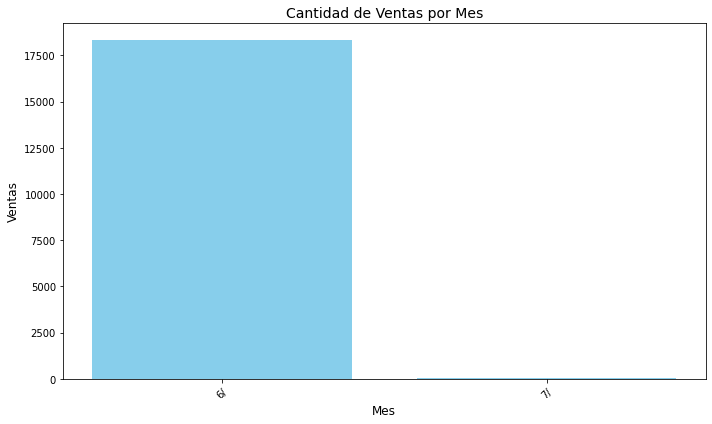

In [0]:
# Convertir el DataFrame de PySpark a Pandas
dfVentas5 = dfVentas4
dfVentas5= dfVentas5.toPandas()

# Crear el histograma
plt.figure(figsize=(10, 6))
plt.bar(dfVentas5["Mes"].astype(str) + "/", 
        dfVentas5["Ventas"], color='skyblue')

plt.title("Cantidad de Ventas por Mes", fontsize=14)
plt.xlabel("Mes", fontsize=12)
plt.ylabel("Ventas", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()

# Mostrar el gráfico
plt.show()

####4.8.- Presente un resumen estadístico del dataframe (1pts)

In [0]:
# Se obtiene el resumen estadístico de todo el DataFrame
dfVentas3.describe().show()

+-------+------------------+--------------------+-------------------+-----------------+-------------------+----------------+--------------------+
|summary|                ID|            Producto|           Cantidad|  Precio_Unitario|                Mes|       Direccion|Ciudad(Departamento)|
+-------+------------------+--------------------+-------------------+-----------------+-------------------+----------------+--------------------+
|  count|             16634|               16634|              16634|            16634|              16634|           16634|               16634|
|   mean|203122.72971023206|                null| 1.1025610195984128|330611.3209089816|  6.001202356618974|            null|                null|
| stddev| 4627.872254486784|                null|0.38699402847799025|533320.1032841252|0.03465520390989596|            null|                null|
|    min|            195098|AA Batteries (4-p...|                  1|          12990.0|                  6|    1 calle 1era|

####4.9.- Se requiere presentar la cantidad de ventas por Ciudad(Departamento) y hacer un histograma (8pts).

In [0]:
dfVentas6 = dfVentas3
# Agrupar por "Ciudad(Departamento)" y sumar las ventas
dfVentas6 = dfVentas6.groupBy("Ciudad(Departamento)").agg(F.sum("Cantidad").alias("Ventas"))

dfVentas6.show(truncate=False)

+--------------------+------+
|Ciudad(Departamento)|Ventas|
+--------------------+------+
| Cúcuta( NS)        |2449  |
| Barranquilla( AT)  |934   |
| Cali( VC)          |1425  |
| Neiva( HU)         |255   |
| Bucaramanga( SA)   |1021  |
| Bogotá( CU)        |2013  |
| Armenia( QU)       |2881  |
| Medellin( AN)      |4484  |
| Manizalez( CA)     |1390  |
| Ibagué( TO)        |1488  |
+--------------------+------+



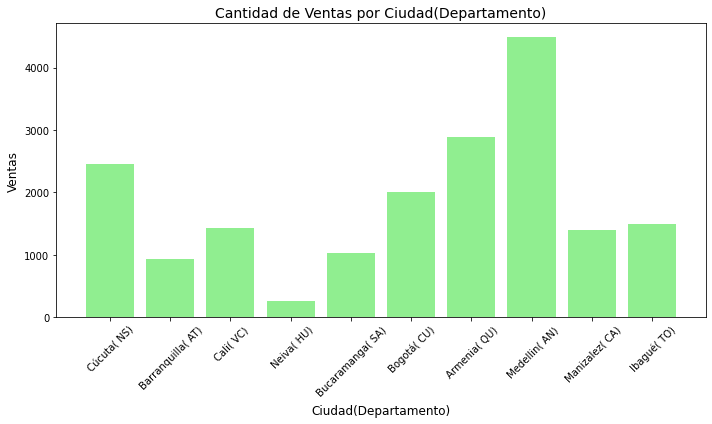

In [0]:
dfVentas6 = dfVentas6.toPandas()

# Crear el histograma (gráfico de barras)
plt.figure(figsize=(10, 6))
plt.bar(dfVentas6["Ciudad(Departamento)"], 
        dfVentas6["Ventas"], color='lightgreen')

plt.title("Cantidad de Ventas por Ciudad(Departamento)", fontsize=14)
plt.xlabel("Ciudad(Departamento)", fontsize=12)
plt.ylabel("Ventas", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()

# Mostrar el gráfico
plt.show()

##5.-Responda justificando las siguientes preguntas (30 pts):
#### 5.1.- Escriba 5 observaciones de la gráfica *4.7* (10 pts)

1. La gráfica muestra una concentración muy alta de ventas en un solo mes (el mes 6). Esto sugiere que pudo ser temporada alta para el producto o servicio que impulsó las ventas en ese mes en particular.
2. La disminución en las ventas del mes 6 al mes 7 es mucho más pronunciada de lo que se podía apreciar en la gráfica anterior. La caída es de más del 90%, lo cual indica un evento o cambio significativo que afectó drásticamente las ventas.
3. La mayoría de las ventas se concentran en un solo mes, ya que la barra correspondiente al mes "6" es significativamente más alta que las demás. Esto sugiere que un solo mes acumuló la mayoría de las ventas. Lo que concuerda con el Conjunto de Datos escogido que fue el de ventas del mes de junio (6)
4. La gráfica muestra una falta de variabilidad en la cantidad de ventas entre los diferentes meses, con la excepción del mes 6. Esto puede indicar que la actividad de ventas es poco constante o que la mayoría de las ventas se concentran en un período específico.
5. El gráfico tiene un rango de valores muy limitado en el eje Y debido a la gran diferencia entre las ventas del mes 6 y 7. Esto hace que las barras del otro mes sea difíci de visualizar, lo que puede dificultar la interpretación detallada de las ventas en el mes con pocos registros.

#### 5.2.-¿Cúal fue la ciudad que más productos vendió? (5 pts)

Según la gráfica en el punto 4.9, la ciudad con más productos vendidos fue Medellín con más de 4000 productos vendidos en el mes de Junio. 

#### 5.3.-¿Cúal es el producto más vendido? (5 pts)

In [0]:
# Crear una nueva columna con solo la primera palabra de cada producto
dfVentas7 = dfVentas2
dfVentas7 = dfVentas7.withColumn("Producto_Simplificado", F.split(F.col("Producto"), " ")[0])

# Mostrar el DataFrame con los productos simplificados
dfVentas7.select("Producto", "Producto_Simplificado").show(truncate=False)


+---------------------------------+---------------------+
|Producto                         |Producto_Simplificado|
+---------------------------------+---------------------+
|Cable de Carga Lightning         |Cable                |
|Cable de Carga Lightning         |Cable                |
|Freidora Air Fryer Kalley K-MAF25|Freidora             |
|AAA Batteries (4-pack)           |AAA                  |
|AA Batteries (4-pack)            |AA                   |
|Xiaomi REDMI Note 8              |Xiaomi               |
|Cable de Carga USB-C P/O         |Cable                |
|AA Batteries (4-pack)            |AA                   |
|Parlante Google HomeMini         |Parlante             |
|Samsung Galaxy A302              |Samsung              |
|Freidora Air Fryer Kalley K-MAF25|Freidora             |
|Asus VivoBook X420FA-BV Laptop   |Asus                 |
|Horno Microondas 0.8P Samsung AGE|Horno                |
|Parlante Google HomeMini         |Parlante             |
|Parlante Goog

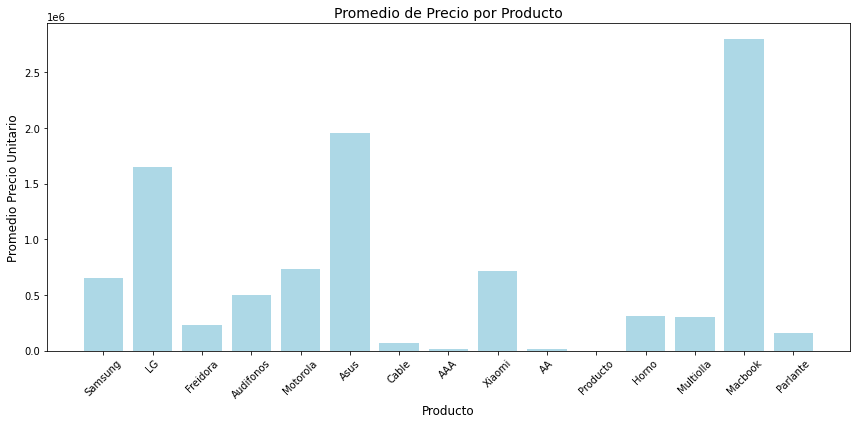

In [0]:

# Calcular el promedio de "Precio_Unitario" por "Producto"
promedio_producto = dfVentas2.groupBy("Producto").agg(F.avg("Precio_Unitario").alias("Promedio_Precio"))

# Simplificar el nombre del producto para tener solo la primera palabra
promedio_producto = promedio_producto.withColumn("Producto_Simplificado", F.split(F.col("Producto"), " ")[0])

# Convertir el DataFrame de PySpark a pandas
promedio_producto_pandas = promedio_producto.select("Producto_Simplificado", "Promedio_Precio").toPandas()

# Crear el gráfico de barras con los nombres de los productos simplificados
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.bar(promedio_producto_pandas["Producto_Simplificado"], 
        promedio_producto_pandas["Promedio_Precio"], color='lightblue')

# Configurar títulos y etiquetas
plt.title("Promedio de Precio por Producto", fontsize=14)
plt.xlabel("Producto", fontsize=12)
plt.ylabel("Promedio Precio Unitario", fontsize=12)
plt.xticks(rotation=45)  # Rotar los nombres de los productos
plt.tight_layout()

# Mostrar el gráfico
plt.show()


Según la tabla obtenida en el punto 4.3 y la gráfica creada, se puede concluir que el producto con más ventas promedio es el "Mackbook". Es el que tiene un precio promedio de más de 2.5 millones de unidades monetarias, muy por encima de cualquier otro producto en la lista. Aunque algunos productos como Asus también tienen un promedio relativamente alto, ninguno se acerca al nivel del Macbook. Esto puede ser debido a que es un dispositivo de alta gama en comparación con otros productos que probablemente tienen un precio más accesible.

#### 5.4.-¿Cúal es el producto menos vendido? (5 pts)

Según la tabla obtenida en el punto 4.3 y la gráfica, se puede decir que el producto "AAA" tiene el promedio de ventas más bajo, lo que indica que su precio unitario promedio es significativamente menor que el del resto de los productos.
Aunque también se ve que los productos "AA" y "Cable" cuentan precios promedio bastante bajos, aunque un poco más altos que "AAA".
Estos productos podrían ser productos de bajo costo, normalmente tienen un precio unitario menor en comparación con productos electrónicos como laptops u otros dispositivos de tecnología.

#### 5.5.-¿Cúal es la proporción de ventas de la ciudad que más vendió productos? (5 pts)

In [0]:
# Agrupar por "Ciudad(Departamento)" y sumar las ventas
dfVentas6 = dfVentas3.groupBy("Ciudad(Departamento)").agg(F.sum("Cantidad").alias("Ventas"))

# Mostrar los resultados
dfVentas6.show(truncate=False)

# 1. Encontrar la ciudad con más ventas
ciudad_max_ventas = dfVentas6.orderBy(F.desc("Ventas")).first()

# 2. Calcular las ventas totales
ventas_totales = dfVentas6.agg(F.sum("Ventas").alias("Total_Ventas")).collect()[0]["Total_Ventas"]

# 3. Calcular la proporción de ventas de la ciudad con más ventas
proporcion_max_ventas = ciudad_max_ventas["Ventas"] / ventas_totales

# 4. Mostrar la proporción en formato porcentaje
print(f"La proporción de ventas de la ciudad que más vendió es: {proporcion_max_ventas:.2%}")

+--------------------+------+
|Ciudad(Departamento)|Ventas|
+--------------------+------+
| Cúcuta( NS)        |2449  |
| Barranquilla( AT)  |934   |
| Cali( VC)          |1425  |
| Neiva( HU)         |255   |
| Bucaramanga( SA)   |1021  |
| Bogotá( CU)        |2013  |
| Armenia( QU)       |2881  |
| Medellin( AN)      |4484  |
| Manizalez( CA)     |1390  |
| Ibagué( TO)        |1488  |
+--------------------+------+

La proporción de ventas de la ciudad que más vendió es: 24.45%


La ciudad que más ventas realizó fue Medellín (AN), con un total de 4,484 ventas. Esto la coloca como la ciudad más fuerte en términos de volumen de ventas en comparación con otras ciudades.
Representa 24.45% del total de ventas de todas las ciudades, lo que es una proporción significativa. Esto indica que casi una cuarta parte de todas las ventas provienen de esta ciudad, destacándola como un mercado clave para los productos vendidos.
